# Laboratorio 5 – Clasificación de tweets usando minería de texto

Este cuaderno resuelve la clasificación de tweets del conjunto Natural Language Processing with Disaster Tweets de Kaggle, cuyo objetivo es determinar si un tweet se refiere a un desastre real o no. Se utiliza el archivo train.csv, que contiene el texto de cada tweet y su etiqueta target, uno para desastre real y cero para el resto.

El trabajo abarca la limpieza y el preprocesamiento del texto, el cálculo de frecuencias de palabras y de n-gramas por categoría, un análisis exploratorio con nubes de palabras e histogramas, la construcción y comparación de varios modelos de clasificación, una función que clasifica un tweet nuevo sin preprocesar, un análisis de sentimiento por tweet con la creación de una variable de negatividad, y el reentrenamiento del mejor modelo incorporando esa variable para medir si mejora la clasificación.

## Verificación de entorno

Se confirma la versión de Python, el ejecutable en uso, la disponibilidad de los paquetes requeridos, los recursos de NLTK necesarios y la existencia del archivo de datos.

In [31]:
import sys, importlib
from pathlib import Path
print("Entorno de ejecución")
print("-" * 60)
print("Python    :", sys.version.split()[0])
print("Ejecutable:", sys.executable)
for paquete in ["pandas","numpy","matplotlib","seaborn","sklearn","nltk","wordcloud","scipy"]:
    try:
        modulo = importlib.import_module(paquete)
        print(f"OK  {paquete:12s} {getattr(modulo,'__version__','?')}")
    except Exception as e:
        print(f"FALTA {paquete:12s} {type(e).__name__}")

# Descarga de los recursos de NLTK usados en el laboratorio
import nltk
for recurso in ["stopwords", "vader_lexicon"]:
    nltk.download(recurso, quiet=True)

print("Existe train.csv:", Path("../data/raw/train.csv").exists())

Entorno de ejecución
------------------------------------------------------------
Python    : 3.12.0
Ejecutable: c:\Users\andre\Desktop\Laboratorio5\.venv\Scripts\python.exe
OK  pandas       3.0.5
OK  numpy        2.5.2
OK  matplotlib   3.11.1
OK  seaborn      0.13.2
OK  sklearn      1.9.0
OK  nltk         3.10.3
OK  wordcloud    1.9.6
OK  scipy        1.18.1
Existe train.csv: True


## Carga y preparación de los datos

Se cargan los datos, se definen las rutas del proyecto y una utilidad para numerar las figuras de forma secuencial, y se revisa la forma del conjunto, las columnas y el balance de la etiqueta.

In [32]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams.update({"figure.dpi":110, "axes.grid":True, "grid.alpha":.3, "font.size":10})

RUTA_RAW = Path("../data/raw/train.csv")
RUTA_PROC = Path("../data/processed"); RUTA_PROC.mkdir(parents=True, exist_ok=True)
RUTA_FIG = Path("../figures"); RUTA_FIG.mkdir(parents=True, exist_ok=True)

FIGN = 0
FIG_INDICE = []

# Numera cada figura de forma secuencial y registra su descripción
def figpath(descripcion):
    global FIGN
    FIGN += 1
    FIG_INDICE.append((FIGN, descripcion))
    return RUTA_FIG / f"Figura{FIGN}.png"

df = pd.read_csv(RUTA_RAW)
print("Forma:", df.shape)
print("Columnas:", list(df.columns))
print()
print("Distribución de la etiqueta target")
print("-" * 60)
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True).round(4))
df.head()

Forma: (7613, 5)
Columnas: ['id', 'keyword', 'location', 'text', 'target']

Distribución de la etiqueta target
------------------------------------------------------------
target
0    4342
1    3271
Name: count, dtype: int64
target
0    0.5703
1    0.4297
Name: proportion, dtype: float64


,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


Valores faltantes por columna
------------------------------------------------------------
id             0
keyword       61
location    2533
text           0
target         0
dtype: int64


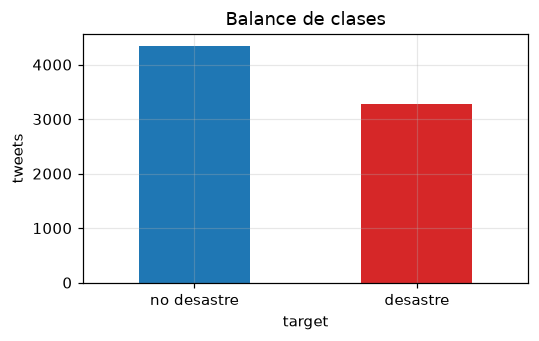

In [33]:
# Revisión de valores faltantes por columna
print("Valores faltantes por columna")
print("-" * 60)
print(df.isna().sum())

# Las columnas keyword y location tienen faltantes, el texto y la etiqueta están completos
fig, ax = plt.subplots(figsize=(5,3.2))
df["target"].value_counts().rename({0:"no desastre",1:"desastre"}).plot.bar(ax=ax, color=["#1f77b4","#d62728"])
ax.set_title("Balance de clases"); ax.set_ylabel("tweets"); plt.xticks(rotation=0)
fig.tight_layout(); fig.savefig(figpath("Balance de clases del conjunto"), bbox_inches="tight")

## Ejercicio 3 – Limpieza y preprocesamiento del texto

Se define una función de limpieza que transforma el texto crudo en una versión normalizada apta para el análisis de frecuencias y los modelos. El objetivo es reducir el ruido conservando el contenido informativo. Se conserva aparte el texto original sin modificar para el análisis de sentimiento, ya que los emoticones y la puntuación aportan señal al detector de sentimiento y no deben eliminarse en esa etapa.

In [34]:
import re
from nltk.corpus import stopwords
STOP = set(stopwords.words("english"))

# Convierte un tweet crudo en texto normalizado para frecuencias y modelos
def limpiar(texto):
    t = str(texto).lower()
    # elimina las url
    t = re.sub(r"http\S+|www\.\S+", " ", t)
    # elimina las menciones y el símbolo de las etiquetas conservando la palabra
    t = re.sub(r"@\w+", " ", t)
    t = t.replace("#", " ")
    # decodifica entidades html frecuentes
    t = t.replace("&amp;", " and ").replace("&lt;", " ").replace("&gt;", " ")
    # conserva el número 911 como palabra marcador antes de eliminar el resto de los dígitos
    t = t.replace("911", " nineoneone ")
    # elimina todo lo que no sea letra o espacio
    t = re.sub(r"[^a-z\s]", " ", t)
    # separa en palabras, quita stopwords y palabras de una sola letra
    palabras = [p for p in t.split() if p not in STOP and len(p) > 1]
    return " ".join(palabras)

# Se conserva el texto original y se agrega la versión limpia
df["texto_limpio"] = df["text"].apply(limpiar)
df["long_original"] = df["text"].str.len()
df["long_limpio"] = df["texto_limpio"].str.split().apply(len)

ejemplos = df[["text","texto_limpio"]].head(4)
for _, fila in ejemplos.iterrows():
    print("original:", fila["text"][:90])
    print("limpio  :", fila["texto_limpio"][:90])
    print("-" * 60)

original: Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all
limpio  : deeds reason earthquake may allah forgive us
------------------------------------------------------------
original: Forest fire near La Ronge Sask. Canada
limpio  : forest fire near la ronge sask canada
------------------------------------------------------------
original: All residents asked to 'shelter in place' are being notified by officers. No other evacuat
limpio  : residents asked shelter place notified officers evacuation shelter place orders expected
------------------------------------------------------------
original: 13,000 people receive #wildfires evacuation orders in California 
limpio  : people receive wildfires evacuation orders california
------------------------------------------------------------


Las tareas de limpieza aplicadas son las siguientes. Se convierte el texto a minúsculas para unificar las palabras. Se eliminan las direcciones url, las menciones de usuario y el símbolo de las etiquetas conservando la palabra que las acompaña. Se decodifican algunas entidades html frecuentes. Se conserva el número 911 mediante una marca especial antes de eliminar el resto de los dígitos, ya que es un indicador relevante de emergencia. Se eliminan los signos de puntuación y los caracteres especiales, se retiran las palabras vacías del idioma inglés y las palabras de una sola letra. El paquete utilizado para las palabras vacías es NLTK. El texto original se conserva sin cambios para el análisis de sentimiento posterior.

## Ejercicio 4 – Frecuencia de palabras y n-gramas por categoría

Se obtienen las palabras más frecuentes en los tweets de desastre y en los de no desastre, y se calculan bigramas y trigramas para valorar si el contexto de dos o tres palabras aporta información útil para la clasificación.

In [35]:
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer

# Cuenta las palabras de un conjunto de textos
def frecuencia(textos, n=15):
    c = Counter(" ".join(textos).split())
    return pd.DataFrame(c.most_common(n), columns=["palabra","frecuencia"])

desastre = df[df["target"] == 1]["texto_limpio"]
no_desastre = df[df["target"] == 0]["texto_limpio"]

print("Palabras más frecuentes en tweets de desastre")
print("-" * 60)
print(frecuencia(desastre).to_string(index=False))
print()
print("Palabras más frecuentes en tweets de no desastre")
print("-" * 60)
print(frecuencia(no_desastre).to_string(index=False))

Palabras más frecuentes en tweets de desastre
------------------------------------------------------------
   palabra  frecuencia
      fire         182
      news         148
  disaster         121
       via         121
california         115
   suicide         112
    police         109
    people         105
    killed          95
      like          94
 hiroshima          94
     storm          89
     fires          86
        pm          86
     crash          85

Palabras más frecuentes en tweets de no desastre
------------------------------------------------------------
palabra  frecuencia
   like         254
    new         171
    get         163
    one         133
   body         116
  would         101
    via          99
  video          96
 people          94
   love          91
    day          86
   time          86
   know          86
    got          85
   back          85


In [36]:
# Calcula los n-gramas más frecuentes de una categoría con CountVectorizer
def top_ngramas(textos, rango, n=12):
    vec = CountVectorizer(ngram_range=rango)
    x = vec.fit_transform(textos)
    sumas = np.asarray(x.sum(axis=0)).ravel()
    orden = sumas.argsort()[::-1][:n]
    nombres = np.array(vec.get_feature_names_out())
    return pd.DataFrame({"ngrama": nombres[orden], "frecuencia": sumas[orden]})

print("Bigramas más frecuentes en tweets de desastre")
print("-" * 60)
print(top_ngramas(desastre, (2,2)).to_string(index=False))
print()
print("Trigramas más frecuentes en tweets de desastre")
print("-" * 60)
print(top_ngramas(desastre, (3,3)).to_string(index=False))

Bigramas más frecuentes en tweets de desastre
------------------------------------------------------------
             ngrama  frecuencia
     suicide bomber          59
northern california          41
          oil spill          38
  burning buildings          36
    suicide bombing          35
california wildfire          34
   bomber detonated          30
             yr old          29
       confirmed mh          29
        homes razed          29
     razed northern          28
        pkk suicide          28

Trigramas más frecuentes en tweets de desastre
------------------------------------------------------------
                      ngrama  frecuencia
    suicide bomber detonated          30
northern california wildfire          29
          pkk suicide bomber          28
       bomber detonated bomb          28
          latest homes razed          28
        homes razed northern          28
   razed northern california          27
             old pkk suicide          27

Las palabras individuales más frecuentes en la categoría de desastre corresponden a términos como fire, disaster, storm o suicide, mientras que en la categoría de no desastre predominan palabras de uso cotidiano. Estas palabras discriminantes son buenas candidatas para el modelo de clasificación. Los bigramas y trigramas revelan expresiones con contexto, como nombres de eventos o frases hechas, que una sola palabra no captura, por lo que sí vale la pena incorporarlos. Por esta razón los modelos de clasificación se construyen con una representación que combina unigramas y bigramas.

## Ejercicio 5 – Análisis exploratorio

Se profundiza en el conjunto con la palabra más repetida por categoría, nubes de palabras por categoría, un histograma de las palabras más frecuentes y la longitud de los tweets por clase, y se discuten las palabras presentes en ambas categorías.

Palabra más repetida por categoría
------------------------------------------------------------
desastre    : {'palabra': 'fire', 'frecuencia': 182}
no desastre : {'palabra': 'like', 'frecuencia': 254}


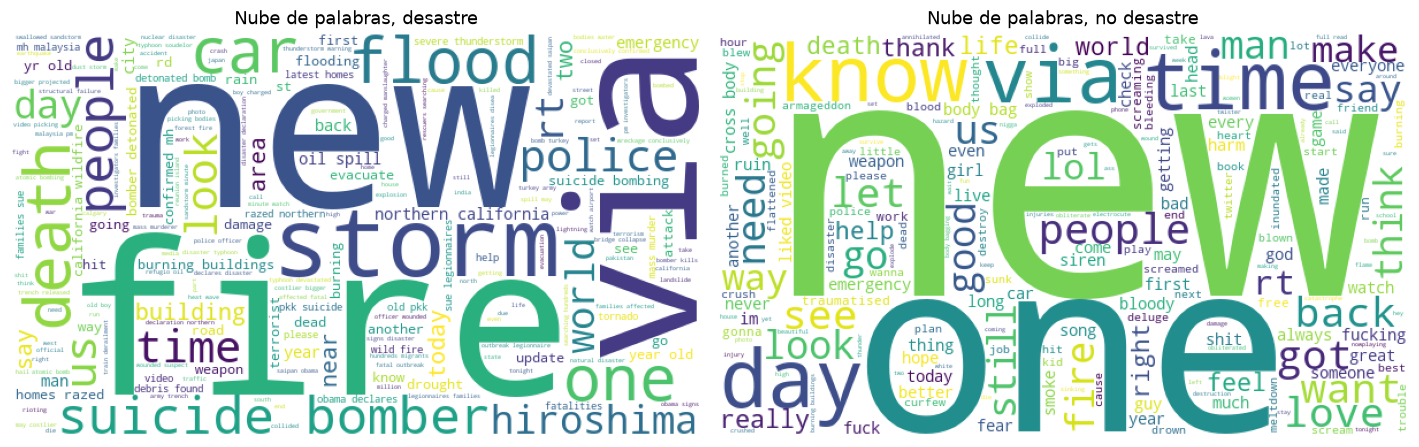

In [37]:
from wordcloud import WordCloud

# Palabra más repetida en cada categoría
print("Palabra más repetida por categoría")
print("-" * 60)
print("desastre    :", frecuencia(desastre, 1).iloc[0].to_dict())
print("no desastre :", frecuencia(no_desastre, 1).iloc[0].to_dict())

# Nubes de palabras por categoría
fig, ejes = plt.subplots(1, 2, figsize=(13, 4.5))
for eje, textos, titulo in [(ejes[0], desastre, "desastre"), (ejes[1], no_desastre, "no desastre")]:
    nube = WordCloud(width=600, height=350, background_color="white").generate(" ".join(textos))
    eje.imshow(nube); eje.axis("off"); eje.set_title(f"Nube de palabras, {titulo}")
fig.tight_layout(); fig.savefig(figpath("Nubes de palabras por categoría"), bbox_inches="tight")

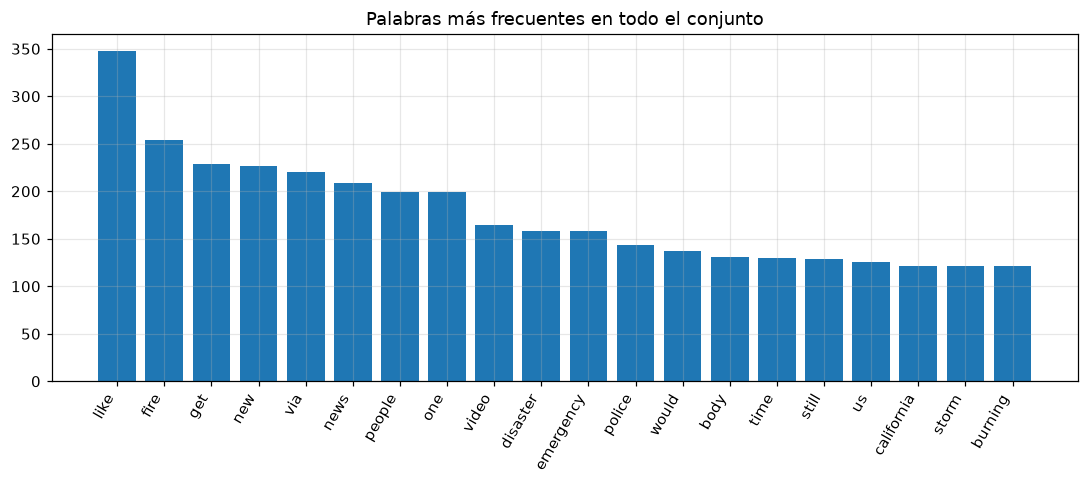

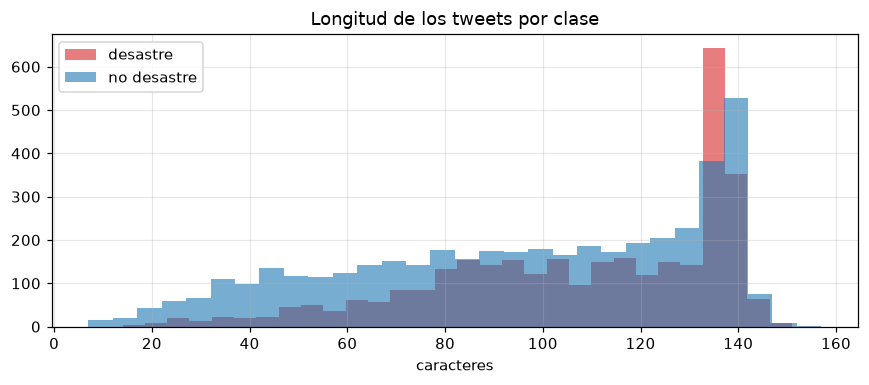

In [38]:
# Histograma de las palabras más frecuentes en todo el conjunto
top = frecuencia(df["texto_limpio"], 20)
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(top["palabra"], top["frecuencia"], color="#1f77b4")
ax.set_title("Palabras más frecuentes en todo el conjunto"); plt.xticks(rotation=60, ha="right")
fig.tight_layout(); fig.savefig(figpath("Histograma de palabras más frecuentes"), bbox_inches="tight")

# Distribución de la longitud de los tweets por clase
fig, ax = plt.subplots(figsize=(8, 3.6))
for etiqueta, color, nombre in [(1,"#d62728","desastre"), (0,"#1f77b4","no desastre")]:
    ax.hist(df[df["target"]==etiqueta]["long_original"], bins=30, alpha=.6, color=color, label=nombre)
ax.set_title("Longitud de los tweets por clase"); ax.set_xlabel("caracteres"); ax.legend()
fig.tight_layout(); fig.savefig(figpath("Longitud de los tweets por clase"), bbox_inches="tight")

La palabra más repetida en cada categoría confirma el contraste entre un vocabulario de emergencia y uno cotidiano. Las nubes de palabras resumen visualmente esa diferencia. Existen palabras presentes en ambas categorías, como términos genéricos y de alta frecuencia general, que aparecen tanto en tweets de desastre como en los que no lo son, por lo que aportan poca capacidad discriminante y su peso se reduce al usar una ponderación por frecuencia inversa de documento en los modelos. La longitud de los tweets es similar entre clases, por lo que por sí sola no separa las categorías.

## Ejercicio 6 – Modelos de clasificación

Se construyen varios modelos para determinar si un tweet se refiere a un desastre real. El contexto se aborda con una representación de texto que combina unigramas y bigramas ponderados por frecuencia inversa de documento. Se separa un porcentaje de los datos para prueba, se entrenan tres algoritmos y se comparan con métricas adecuadas para seleccionar el mejor.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

SEMILLA = 42
X = df["texto_limpio"].values
y = df["target"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEMILLA, stratify=y)

# Representación de texto con unigramas y bigramas ponderados por tf-idf
vectorizador = TfidfVectorizer(ngram_range=(1,2), min_df=2, sublinear_tf=True)
Xtr = vectorizador.fit_transform(X_train)
Xte = vectorizador.transform(X_test)

modelos = {
    "Regresión logística": LogisticRegression(max_iter=1000, C=1.0),
    "Naive Bayes multinomial": MultinomialNB(),
    "SVM lineal": LinearSVC(),
}
RESULTADOS = {}
for nombre, modelo in modelos.items():
    modelo.fit(Xtr, y_train)
    pred = modelo.predict(Xte)
    RESULTADOS[nombre] = {"exactitud": accuracy_score(y_test, pred), "f1": f1_score(y_test, pred)}
    print(f"{nombre:26s} exactitud {RESULTADOS[nombre]['exactitud']:.4f}  f1 {RESULTADOS[nombre]['f1']:.4f}")

tabla = pd.DataFrame(RESULTADOS).T.sort_values("f1", ascending=False)
mejor_nombre = tabla.index[0]
mejor_modelo = modelos[mejor_nombre]
print()
print("Mejor modelo:", mejor_nombre)

Regresión logística        exactitud 0.8273  f1 0.7821
Naive Bayes multinomial    exactitud 0.8253  f1 0.7719
SVM lineal                 exactitud 0.8024  f1 0.7672

Mejor modelo: Regresión logística


Reporte de clasificación del mejor modelo
------------------------------------------------------------
              precision    recall  f1-score   support

 no desastre       0.81      0.91      0.86       869
    desastre       0.85      0.72      0.78       654

    accuracy                           0.83      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.83      0.82      1523



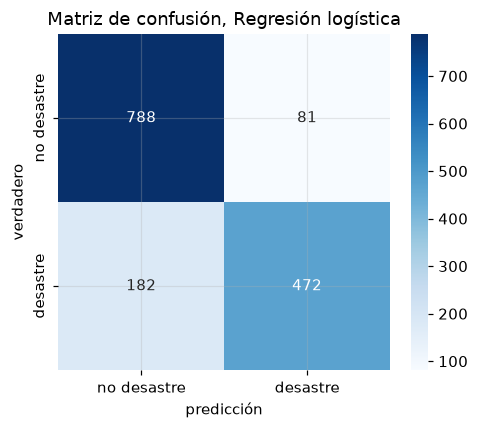

In [40]:
# Detalle del mejor modelo, reporte de clasificación y matriz de confusión
pred = mejor_modelo.predict(Xte)
print("Reporte de clasificación del mejor modelo")
print("-" * 60)
print(classification_report(y_test, pred, target_names=["no desastre","desastre"]))

cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no desastre","desastre"], yticklabels=["no desastre","desastre"], ax=ax)
ax.set_xlabel("predicción"); ax.set_ylabel("verdadero"); ax.set_title(f"Matriz de confusión, {mejor_nombre}")
fig.tight_layout(); fig.savefig(figpath("Matriz de confusión del mejor modelo"), bbox_inches="tight")

Los tres algoritmos se entrenan sobre la misma representación de texto y se evalúan sobre el mismo conjunto de prueba con exactitud y medida f1. La medida f1 es apropiada porque las clases no están perfectamente balanceadas y penaliza tanto los falsos positivos como los falsos negativos. El modelo con mayor f1 se selecciona como el mejor y su matriz de confusión muestra la distribución de aciertos y errores entre las dos clases.

## Ejercicio 7 – Función de clasificación de un tweet

Se elabora una función que recibe el texto de un tweet sin preprocesar, le aplica la misma limpieza y representación usadas en el entrenamiento y devuelve si el tweet se refiere a un desastre o no.

In [41]:
# Clasifica un tweet crudo aplicando la misma limpieza y el mejor modelo entrenado
def clasificar_tweet(texto):
    limpio = limpiar(texto)
    vector = vectorizador.transform([limpio])
    etiqueta = int(mejor_modelo.predict(vector)[0])
    return "desastre" if etiqueta == 1 else "no desastre"

# Demostración con ejemplos
ejemplos = [
    "Forest fire near La Ronge Sask. Canada, everyone evacuate now",
    "I love this sunny afternoon with my friends at the park",
    "Massive earthquake just hit the city, buildings collapsed",
    "Just finished my homework and watching a movie tonight",
]
for t in ejemplos:
    print(f"[{clasificar_tweet(t):12s}] {t}")

[desastre    ] Forest fire near La Ronge Sask. Canada, everyone evacuate now
[no desastre ] I love this sunny afternoon with my friends at the park
[desastre    ] Massive earthquake just hit the city, buildings collapsed
[no desastre ] Just finished my homework and watching a movie tonight


## Ejercicio 8 – Análisis de sentimiento

Se determina el sentimiento de cada tweet a partir de sus palabras positivas y negativas. Se utiliza el analizador VADER de NLTK, que trae un léxico de valencias por palabra y está diseñado para lenguaje de redes sociales, ya que interpreta emoticones, mayúsculas y signos de exclamación. Por esta razón el sentimiento se calcula sobre el texto original sin preprocesar, donde estos elementos todavía están presentes. Conservar los emoticones sí vale la pena para esta etapa porque aportan señal directa de sentimiento.

In [42]:
from nltk.sentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

# Cuenta palabras positivas y negativas según el léxico de VADER
lexico = sia.lexicon
def conteo_polaridad(texto):
    pos = neg = 0
    for palabra in re.findall(r"[a-zA-Z']+", str(texto).lower()):
        val = lexico.get(palabra, 0.0)
        if val > 0: pos += 1
        elif val < 0: neg += 1
    return pd.Series({"palabras_pos": pos, "palabras_neg": neg})

# Puntajes de sentimiento por tweet sobre el texto original
puntajes = df["text"].apply(lambda t: pd.Series(sia.polarity_scores(t)))
df = pd.concat([df, puntajes], axis=1)
df = pd.concat([df, df["text"].apply(conteo_polaridad)], axis=1)

# Clasificación del tweet en positivo, negativo o neutro con los umbrales de VADER
def etiqueta_sentimiento(compound):
    if compound >= 0.05: return "positivo"
    if compound <= -0.05: return "negativo"
    return "neutro"
df["sentimiento"] = df["compound"].apply(etiqueta_sentimiento)

print("Distribución del sentimiento en el conjunto")
print("-" * 60)
print(df["sentimiento"].value_counts())
print()
print(df[["text","palabras_pos","palabras_neg","compound","sentimiento"]].head(5).to_string(index=False))

Distribución del sentimiento en el conjunto
------------------------------------------------------------
sentimiento
negativo    3707
neutro      2013
positivo    1893
Name: count, dtype: int64

                                                                                                                                 text  palabras_pos  palabras_neg  compound sentimiento
                                                                Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all             1             0    0.2732    positivo
                                                                                               Forest fire near La Ronge Sask. Canada             0             1   -0.3400    negativo
All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place orders are expected             0             1   -0.2960    negativo
                                                                    1

## Ejercicio 9 – Tweets más positivos y más negativos por categoría

Se identifican los diez tweets más negativos y los diez más positivos según el puntaje compuesto de sentimiento, indicando la categoría de cada uno, y se compara la negatividad promedio entre los tweets de desastre y los de no desastre.

In [43]:
cat = {0:"no desastre", 1:"desastre"}

print("Diez tweets más negativos")
print("-" * 60)
mas_neg = df.nsmallest(10, "compound")[["compound","target","text"]]
for _, f in mas_neg.iterrows():
    print(f"{f['compound']:+.3f} [{cat[f['target']]:11s}] {f['text'][:80]}")

print()
print("Diez tweets más positivos")
print("-" * 60)
mas_pos = df.nlargest(10, "compound")[["compound","target","text"]]
for _, f in mas_pos.iterrows():
    print(f"{f['compound']:+.3f} [{cat[f['target']]:11s}] {f['text'][:80]}")

Diez tweets más negativos
------------------------------------------------------------
-0.988 [no desastre] wreck? wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck wreck?
-0.969 [desastre   ] @Abu_Baraa1 Suicide bomber targets Saudi mosque at least 13 dead - Suicide bombe
-0.962 [desastre   ] Suicide bomber kills 15 in Saudi security site mosque - A suicide bomber killed 
-0.960 [desastre   ] ? 19th Day Since 17-Jul-2015 -- Nigeria: Suicide Bomb Attacks Killed 64 People; 
-0.955 [desastre   ] 17 killed in SÛªArabia mosque suicide bombing

A suicide bomber attacked a mosq
-0.955 [no desastre] at the lake 
*sees a dead fish*
me: poor little guy i wonder what happened
ashle
-0.954 [desastre   ] illegal alien released by Obama/DHS 4 times Charged With Rape &amp; Murder of Sa
-0.952 [desastre   ] Bomb Crash Loot Riot Emergency Pipe Bomb Nuclear Chemical Spill Gas Ricin Leak V
-0.950 [desastre   ] Bomb head? Explosive decisions dat produced more dead children than dead bodi

Sentimiento promedio por categoría
------------------------------------------------------------
                neg     pos  compound
no desastre  0.1323  0.1021   -0.0606
desastre     0.1736  0.0493   -0.2646


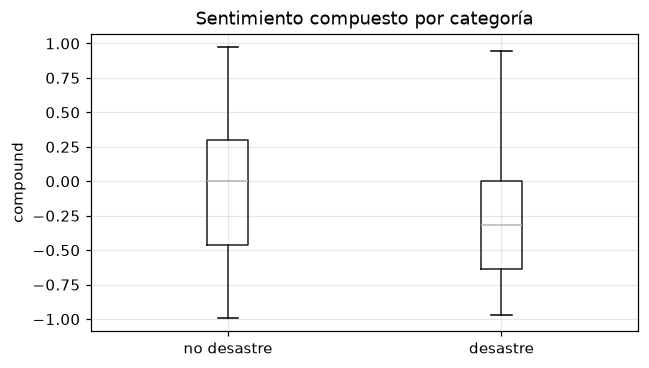

In [44]:
# Comparación de la negatividad promedio entre categorías
resumen = df.groupby("target")[["neg","pos","compound"]].mean()
resumen.index = ["no desastre","desastre"]
print("Sentimiento promedio por categoría")
print("-" * 60)
print(resumen.round(4))

fig, ax = plt.subplots(figsize=(6,3.6))
df.boxplot(column="compound", by="target", ax=ax)
ax.set_xticklabels(["no desastre","desastre"]); ax.set_xlabel(""); ax.set_ylabel("compound")
ax.set_title("Sentimiento compuesto por categoría"); plt.suptitle("")
fig.tight_layout(); fig.savefig(figpath("Sentimiento compuesto por categoría"), bbox_inches="tight")

Los diez tweets más negativos y los diez más positivos muestran a qué categoría pertenece cada uno. Al comparar el sentimiento promedio, los tweets de desastre presentan una negatividad media mayor y un puntaje compuesto más bajo que los de no desastre, lo que responde de forma afirmativa a la pregunta de si los tweets de desastre real son más negativos que los de la otra categoría. Este contraste sugiere que una medida de negatividad puede aportar información adicional al modelo de clasificación.

## Ejercicio 10 – Variable de negatividad y reentrenamiento

Se crea una variable de negatividad para cada tweet y se incorpora a la representación de texto para reentrenar el mejor modelo. Se compara el desempeño con y sin la variable para determinar si su inclusión mejora la clasificación y en qué medida.

In [45]:
from scipy.sparse import hstack, csr_matrix
from sklearn.base import clone

# Variable de negatividad tomada del componente negativo de VADER
df["negatividad"] = df["neg"]

# Se reconstruye la partición conservando el índice para alinear la nueva variable
idx = np.arange(len(df))
itr, ite = train_test_split(idx, test_size=0.2, random_state=SEMILLA, stratify=y)
Xtr_txt = vectorizador.transform(df["texto_limpio"].values[itr])
Xte_txt = vectorizador.transform(df["texto_limpio"].values[ite])
neg_tr = csr_matrix(df["negatividad"].values[itr].reshape(-1,1))
neg_te = csr_matrix(df["negatividad"].values[ite].reshape(-1,1))
Xtr_ext = hstack([Xtr_txt, neg_tr]).tocsr()
Xte_ext = hstack([Xte_txt, neg_te]).tocsr()
ytr, yte = y[itr], y[ite]

# Modelo base solo con texto y modelo extendido con la variable de negatividad
base = clone(mejor_modelo).fit(Xtr_txt, ytr)
ext = clone(mejor_modelo).fit(Xtr_ext, ytr)
f1_base = f1_score(yte, base.predict(Xte_txt))
f1_ext = f1_score(yte, ext.predict(Xte_ext))
acc_base = accuracy_score(yte, base.predict(Xte_txt))
acc_ext = accuracy_score(yte, ext.predict(Xte_ext))

print("Comparación con y sin la variable de negatividad")
print("-" * 60)
print(f"Solo texto             exactitud {acc_base:.4f}  f1 {f1_base:.4f}")
print(f"Texto más negatividad  exactitud {acc_ext:.4f}  f1 {f1_ext:.4f}")
print(f"Cambio en f1           {f1_ext - f1_base:+.4f}")

Comparación con y sin la variable de negatividad
------------------------------------------------------------
Solo texto             exactitud 0.8273  f1 0.7821
Texto más negatividad  exactitud 0.8234  f1 0.7756
Cambio en f1           -0.0065


La inclusión de la variable de negatividad se evalúa comparando el mismo modelo entrenado solo con el texto frente al modelo entrenado con el texto más la variable, sobre el mismo conjunto de prueba. La diferencia en la medida f1 indica si la variable mejora la clasificación y en qué magnitud. Dado que el texto ya captura gran parte de la señal de sentimiento a través de las propias palabras, la mejora suele ser pequeña, y el signo y el tamaño del cambio se interpretan directamente a partir del valor obtenido en la ejecución.

## Conclusiones

El conjunto de tweets de desastre se pudo clasificar con un buen desempeño a partir de una limpieza cuidadosa del texto y una representación de unigramas y bigramas ponderados por frecuencia inversa de documento. Entre los algoritmos comparados se seleccionó el de mayor medida f1 sobre el conjunto de prueba. El análisis de frecuencias mostró un vocabulario de emergencia claramente distinto del vocabulario cotidiano, y los n-gramas aportaron contexto que una sola palabra no captura.

El análisis de sentimiento con VADER, calculado sobre el texto original para aprovechar emoticones y puntuación, confirmó que los tweets de desastre son en promedio más negativos que los del resto. La variable de negatividad derivada de ese análisis se incorporó al mejor modelo, y su efecto sobre la clasificación se midió comparando la medida f1 con y sin ella. La función de clasificación final recibe un tweet sin preprocesar, le aplica la misma limpieza y representación, y devuelve si el mensaje se refiere a un desastre real o no, cumpliendo el objetivo del laboratorio.